In [1]:
from sircuitenum import qpackage_interface as pi
from sircuitenum import utils
from sircuitenum import enumerate as enum
from sircuitenum import visualize as viz
from sircuitenum import quantize

from IPython.display import display, Math

from itertools import product
from functools import reduce

import sympy as sym
from sympy import latex, collect, expand_mul, Mul, Dummy
from sympy.core.add import Add
from sympy.core.symbol import Symbol

import numpy as np

# Quantize Single $0-\pi$

## Usual Change of Basis:

### All Params the Same:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

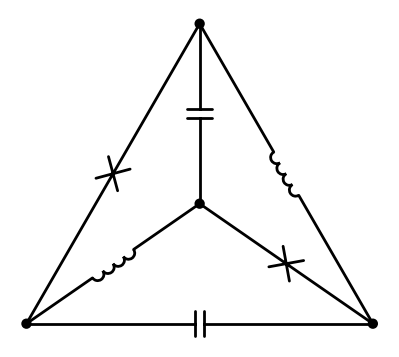

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [2]:
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",),("J",), ("L",), ("L",), ("C",), ("C",)]
# circuit = [("J1",),("J2",), ("L1",), ("L2",), ("C",), ("C",)]

R = sym.Rational(1,2)*sym.Matrix([[-1, 1, -1,  1],
                                  [-1, 1,  1, -1],
                                  [1,  1, -1, -1],
                                  [1,  1,  1,  1]])
Z = sym.inv_quick(R)
display(Math(r"Z = " + sym.latex(Z)))
display(Math(r"$Z^T = " + sym.latex(Z.transpose()) + r"$"))

viz.draw_circuit_diagram(circuit, edges, out = "", layout="fixed")

H, C_mat, L_mat = quantize.quantize_circuit(circuit, edges, cob=Z, free=[4], return_mats=True)
display(Math("[C]_{ij} = " + sym.latex(C_mat)))
display(Math("[L]_{ij} = " + sym.latex(L_mat)))
Math("\hat{H} = "+sym.latex(H))


### Parameters not the same

<IPython.core.display.Math object>

<IPython.core.display.Math object>

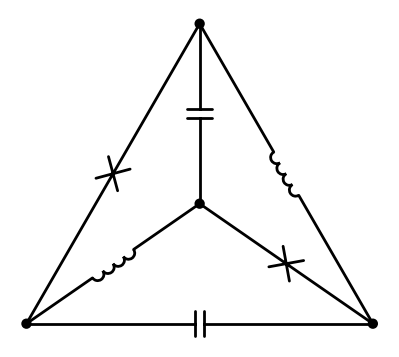

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J1",),("J2",), ("L1",), ("L2",), ("C1",), ("C2",)]

R = sym.Rational(1,2)*sym.Matrix([[-1, 1, -1,  1],
                                  [-1, 1,  1, -1],
                                  [1,  1, -1, -1],
                                  [1,  1,  1,  1]])
Z = sym.inv_quick(R)
display(Math(r"Z = " + sym.latex(Z)))
display(Math(r"$Z^T = " + sym.latex(Z.transpose()) + r"$"))

viz.draw_circuit_diagram(circuit, edges, out = "", layout="fixed")

H, C_mat, L_mat = quantize.quantize_circuit(circuit, edges, cob=Z, free=[4], return_mats=True)
display(Math("[C]_{ij} = " + sym.latex(C_mat)))
display(Math("[L]_{ij} = " + sym.latex(L_mat)))
Math("\hat{H} = "+sym.latex(H))


# Quantize Two 0-$\pi$

## Layout 1: Complex Circuit Simple Coupling

<IPython.core.display.Math object>

<IPython.core.display.Math object>

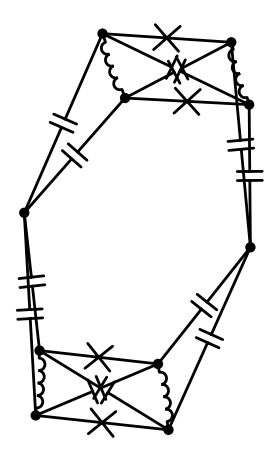

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
# Individual Zero Pi
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",),("J",), ("L",), ("L",), ("C",), ("C",)]
edges += [(x[0] + 4, x[1] + 4) for x in edges]
circuit += circuit

# Coupling
edges += [(1, 10), (4, 10), (5, 10), (8, 10), (2, 9), (3, 9), (6, 9), (7, 9)]
circuit += [("C_c",)]*8

# Transformation
R = sym.Rational(1,2)*sym.Matrix([[-1, 1, -1,  1,  0,  0,  0,  0,  0,  0],
                                  [-1, 1,  1, -1,  0,  0,  0,  0,  0,  0],
                                  [1,  1, -1, -1,  0,  0,  0,  0,  0,  0],
                                  [1,  1,  1,  1,  0,  0,  0,  0,  0,  0],
                                  [0,  0,  0,  0, -1,  1,  -1,  1, 0,  0],
                                  [0,  0,  0,  0, -1,  1,   1, -1, 0, 0],
                                  [0,  0,  0,  0,  1,  1,  -1, -1, 0, 0],
                                  [0,  0,  0,  0,  1,  1,   1,  1, 0, 0],
                                  [0,  0,  0,  0,  0,  0,  0,  0,  -1, 1],
                                  [0,  0,  0,  0,  0,  0,  0,  0,  1, 1]])
Z = sym.inv_quick(R)
display(Math(r"Z = " + sym.latex(Z)))
display(Math(r"$Z^T = " + sym.latex(Z.transpose()) + r"$"))

viz.draw_circuit_diagram(circuit, edges, out = "", layout="spring")

H, C_mat, L_mat = quantize.quantize_circuit(circuit, edges, cob=Z, free=[4, 8, 10], return_mats=True)
display(Math("[C]_{ij} = " + sym.latex(C_mat)))
display(Math("[L]_{ij} = " + sym.latex(L_mat)))
Math("\hat{H} = "+sym.latex(H))

Assuming $C >> C_c >> C_J$ see that the coefficient for $\theta_1 \theta_2$ coupling ($q_2 q_6$) goes with:

$$g_{\theta_1,\theta_2} \propto \frac{C_c}{C2} = \frac{\textrm{medium}}{\textrm{big}^2}$$

while the coefficients coupling the $\theta$ modes with the free mode ($q_2 q_9$ and $q_6 q_9$) go with:

$$g_{\theta, \textrm{free}} \propto \frac{1}{C} = \frac{1}{\textrm{big}}$$

Is there any way to improve the scaling for the coupling we want?

One other concern here is that in order to increase the coupling between the $\theta$ modes, we have to increase $C_c$, which which will make the $\phi$ modes heavier.

## Layout 2: Simpler Circuit More Complex Coupling

<IPython.core.display.Math object>

<IPython.core.display.Math object>

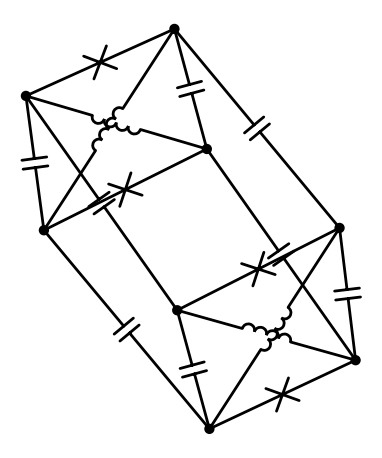

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",),("J",), ("L",), ("L",), ("C",), ("C",)]

edges += [(x[0] + 4, x[1] + 4) for x in edges]
circuit += circuit

edges += [(2, 7), (1, 8), (3, 6), (4, 5)]
circuit += [("C_c",)]*4

# Transformation
R = sym.Rational(1,2)*sym.Matrix([[-1, 1, -1,  1,  0,  0,  0,  0],
                                  [-1, 1,  1, -1,  0,  0,  0,  0],
                                  [1,  1, -1, -1,  0,  0,  0,  0],
                                  [1,  1,  1,  1,  0,  0,  0,  0],
                                  [0,  0,  0,  0, -1,  1,  -1,  1],
                                  [0,  0,  0,  0, -1,  1,   1, -1],
                                  [0,  0,  0,  0,  1,  1,  -1, -1],
                                  [0,  0,  0,  0,  1,  1,   1,  1]])
Z = sym.inv_quick(R)

display(Math(r"Z = " + sym.latex(Z)))
display(Math(r"$Z^T = " + sym.latex(Z.transpose()) + r"$"))

viz.draw_circuit_diagram(circuit, edges, out = "", layout="spring")

H, C_mat, L_mat = quantize.quantize_circuit(circuit, edges, cob=Z, free=[4, 8], return_mats=True)
display(Math("[C]_{ij} = " + sym.latex(C_mat)))
display(Math("[L]_{ij} = " + sym.latex(L_mat)))
Math("\hat{H} = "+sym.latex(H))

Again assuming $C >> C_c >> C_J$ see that the coefficient for the respective modes go with:

$$g_{\phi_1,\phi_2} \propto \frac{1}{C_J} = \frac{1}{\textrm{small}}$$
$$g_{\theta_1,\theta_2} \propto \frac{C_c}{C^2} = \frac{\textrm{medium}}{\textrm{big}^2}$$
$$g_{\zeta_1,\zeta_2} \propto \frac{C_c}{C^2} = \frac{\textrm{medium}}{\textrm{big}^2}$$

The $\theta_1 \theta_2$ coupling remains the same as the more complicated circuit, but now we have the following questions:

1) Does the strong $\phi_1 \phi_2$ coupling matter?
2) Does the $\zeta_1 \zeta_2$ coupling matter?

One good thing here is that the coupling capacitance shows up differently in $E_{C\phi}$, so increasing the coupling capacitance won't change the lightness of the $\phi$ mode much compared with the more complicated circuit.

I wonder if there is a coupling that can give us the $\frac{1}{C}$ scaling that we got with the free mode in the more complicated example?